<a href="https://colab.research.google.com/github/Shubham28g2004/heart-disease-pred-ml/blob/main/heart_disease_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Basic Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB
None

Shape: (920, 16)

Numerical Summary:
                id         age    trestbps        chol      thalch     ol

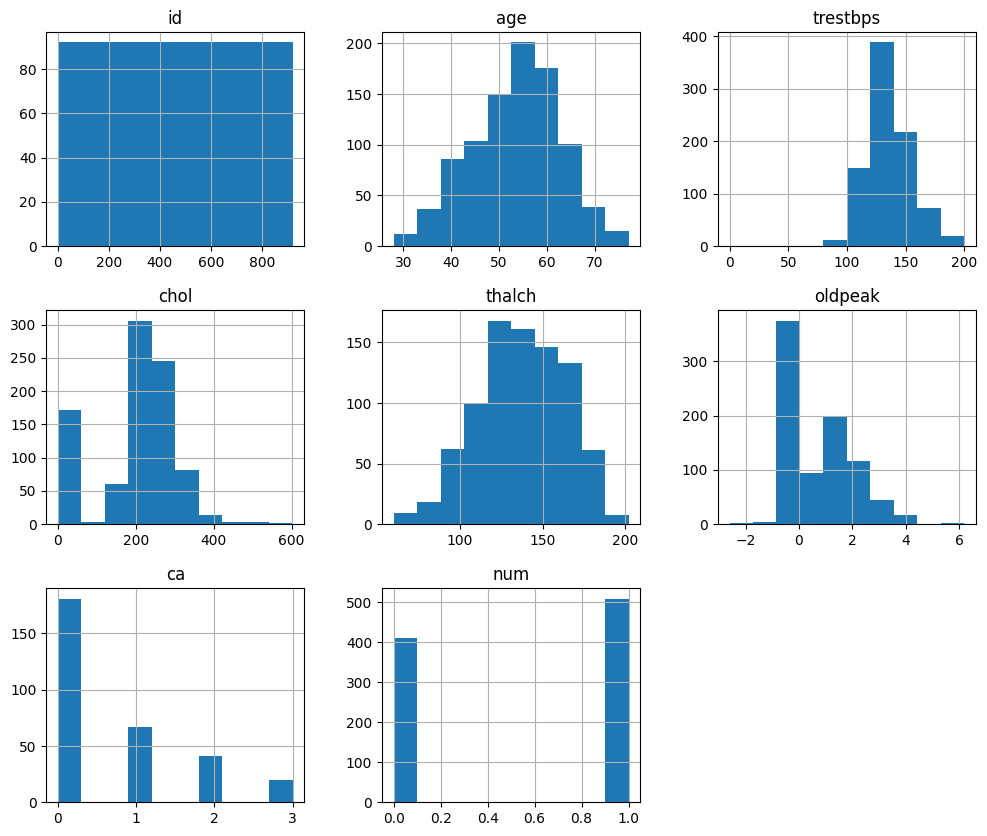

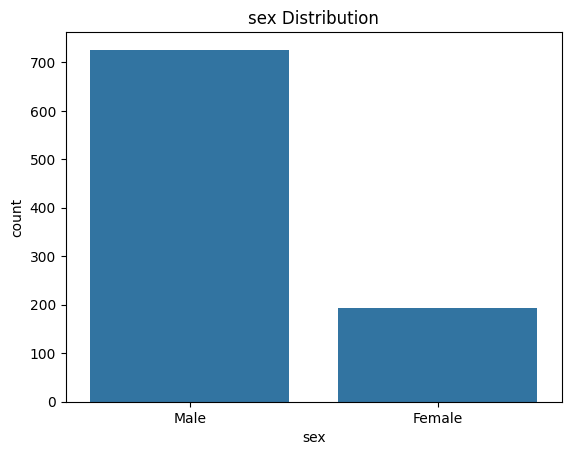

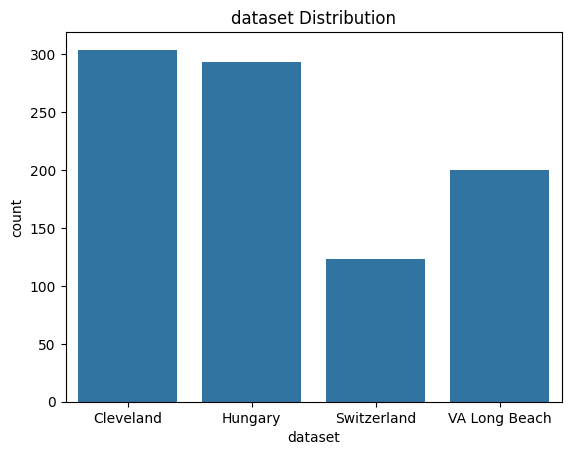

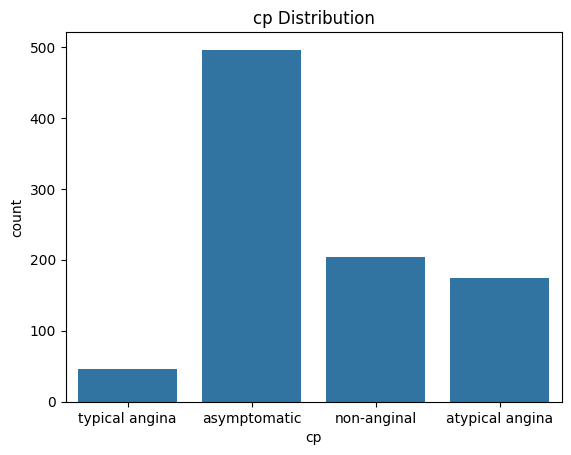

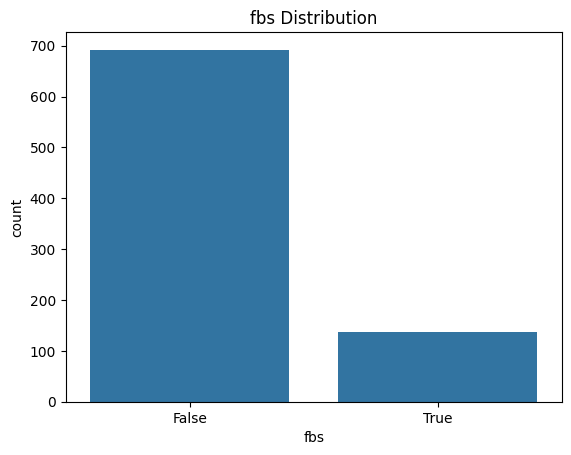

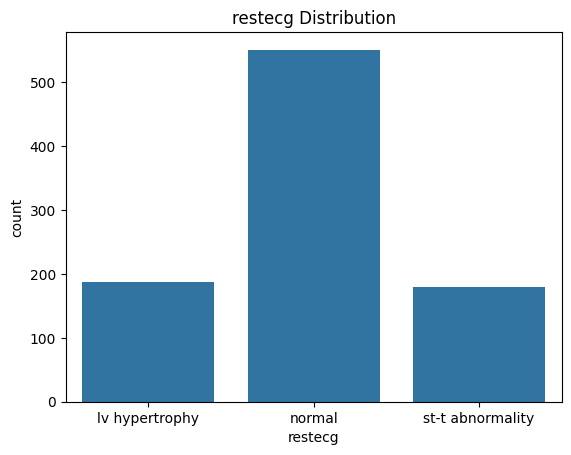

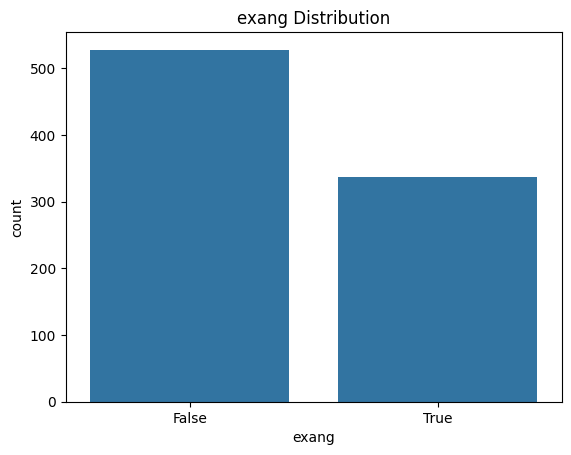

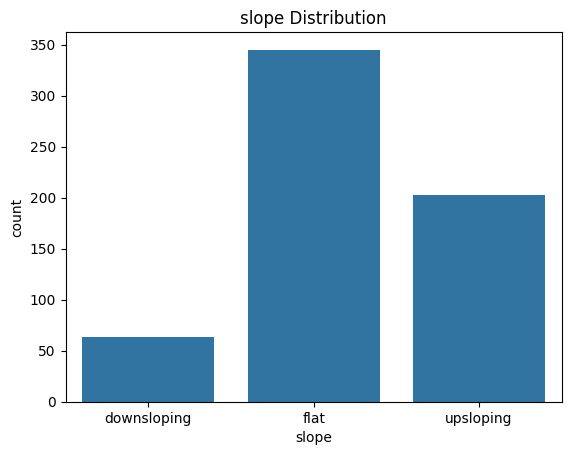

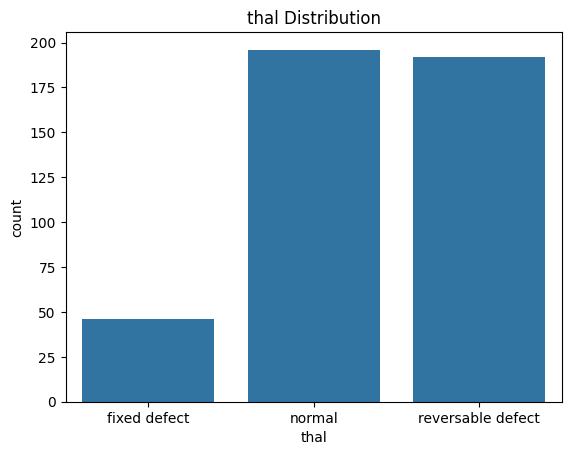

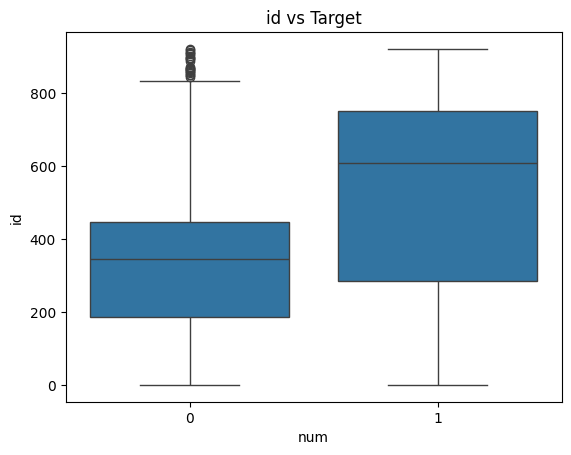

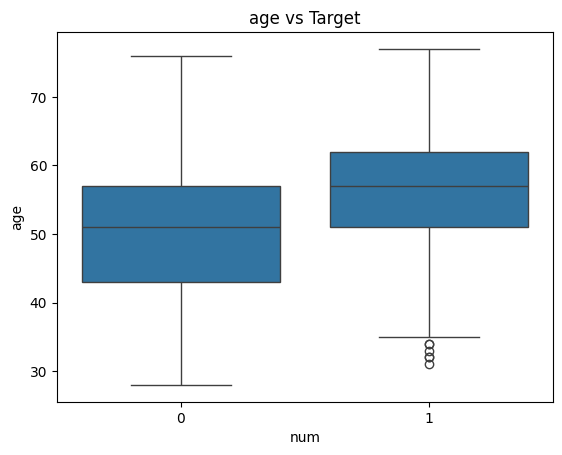

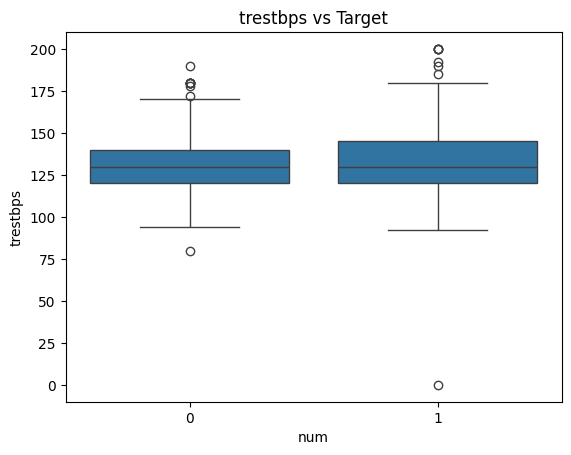

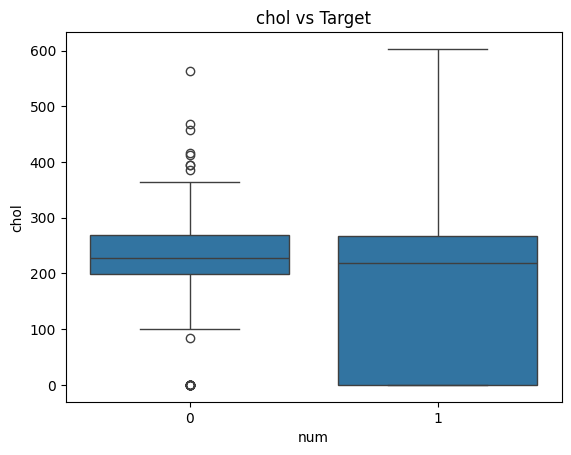

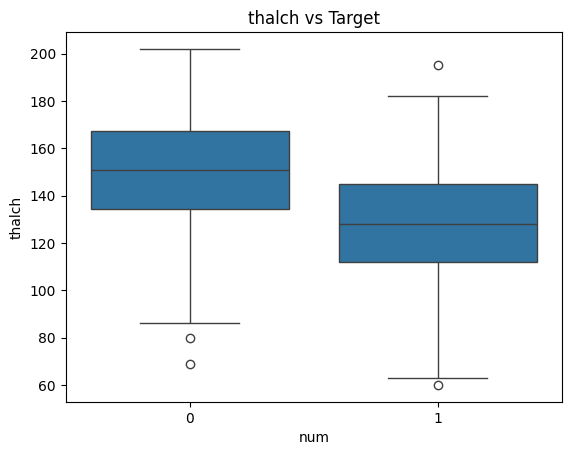

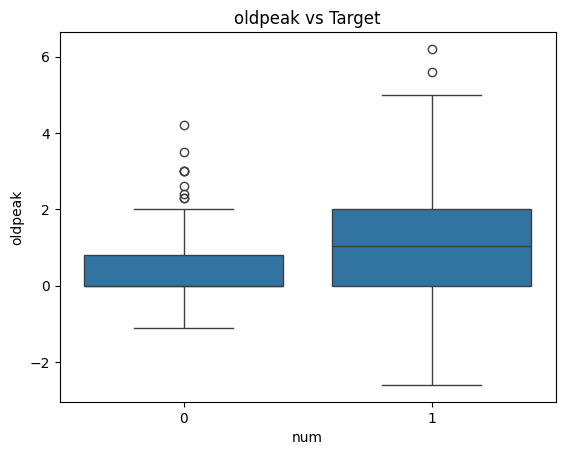

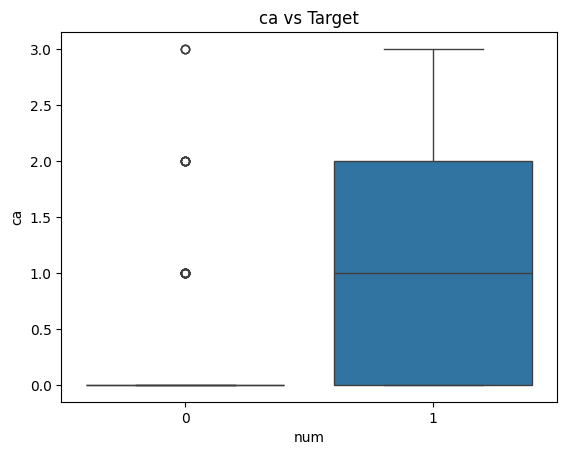

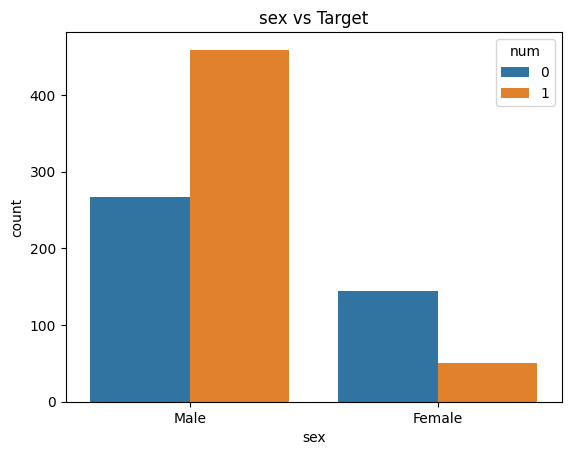

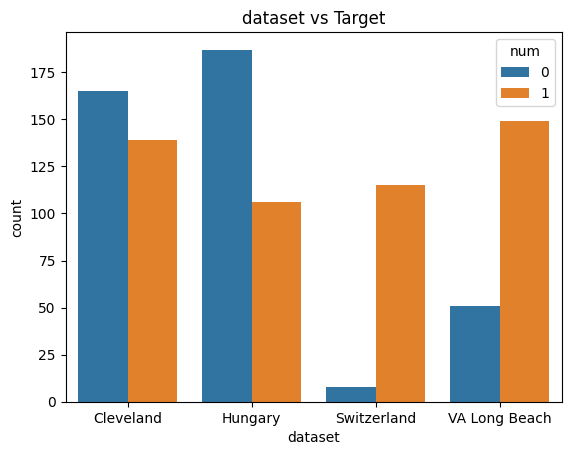

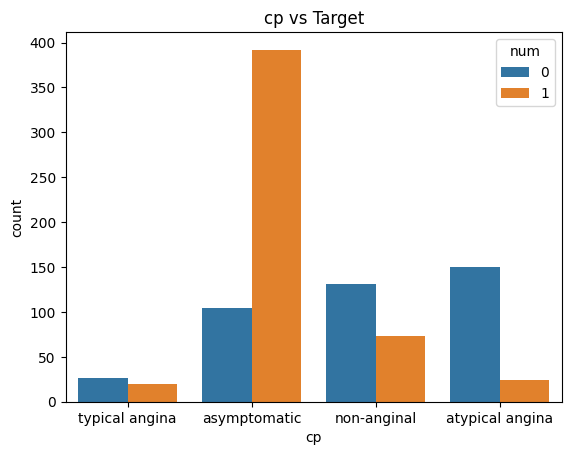

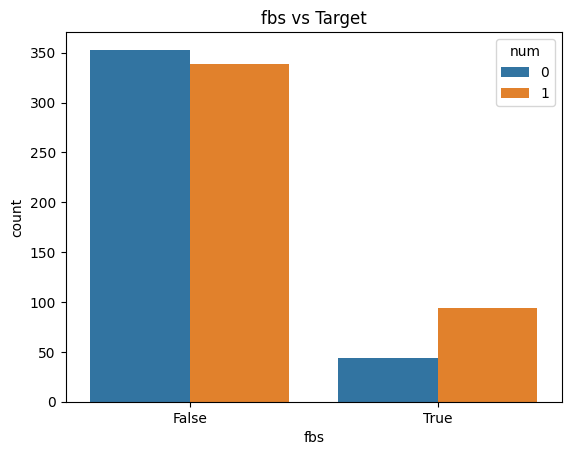

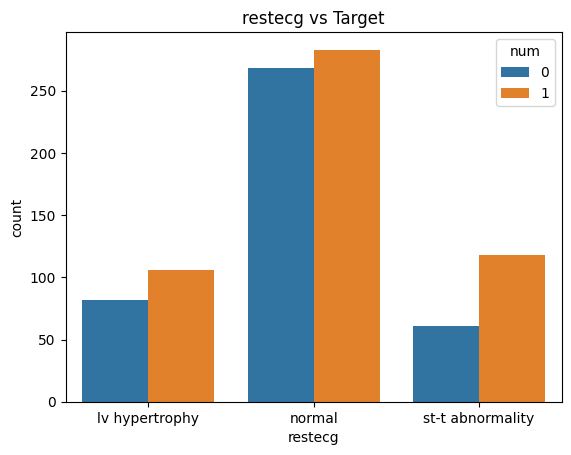

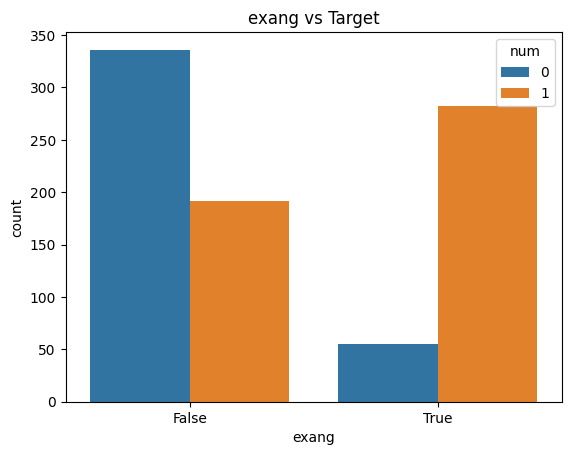

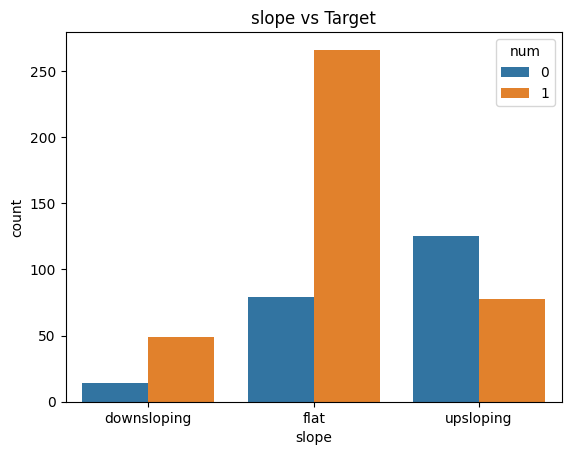

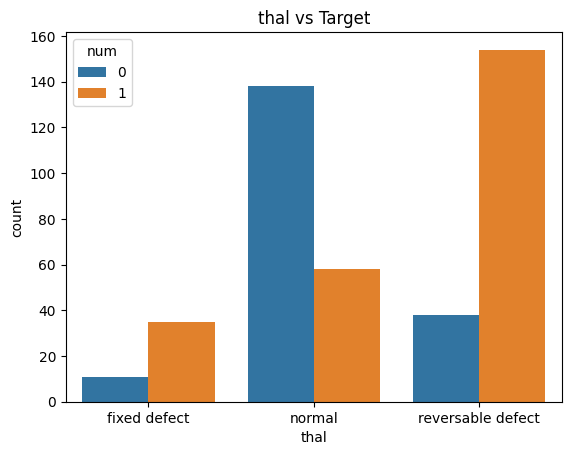

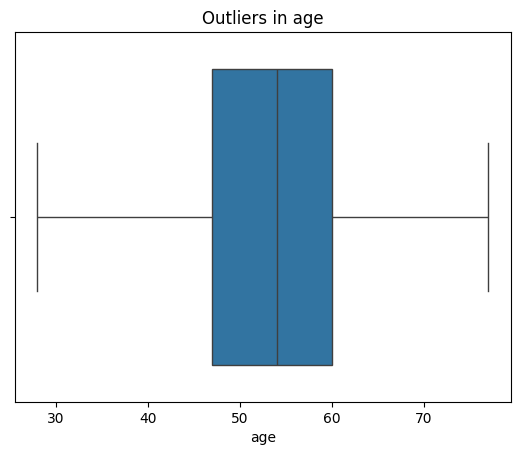

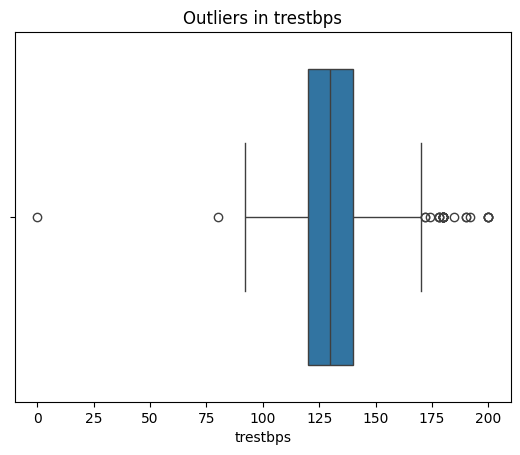

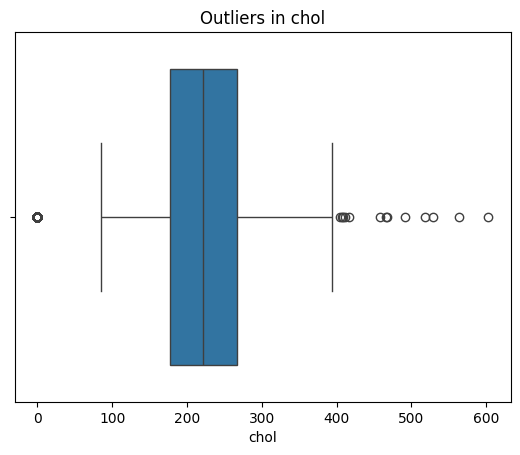

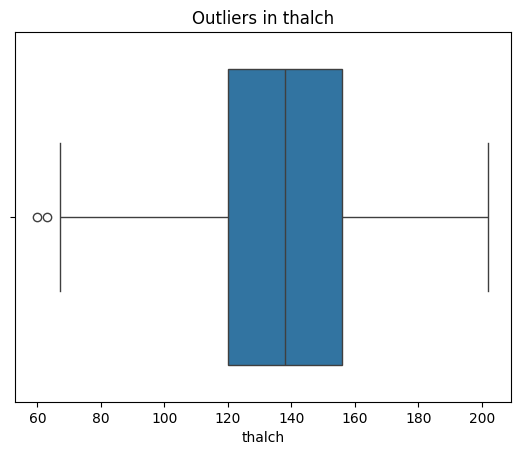

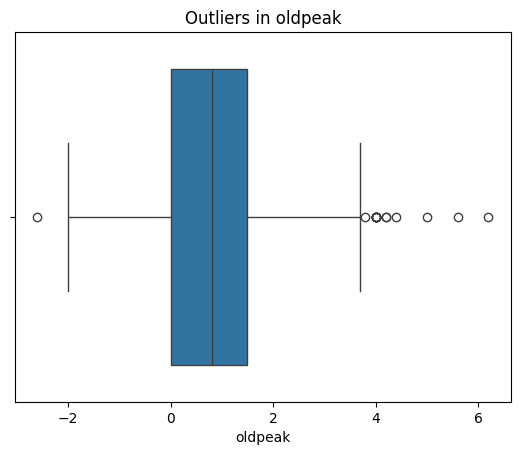

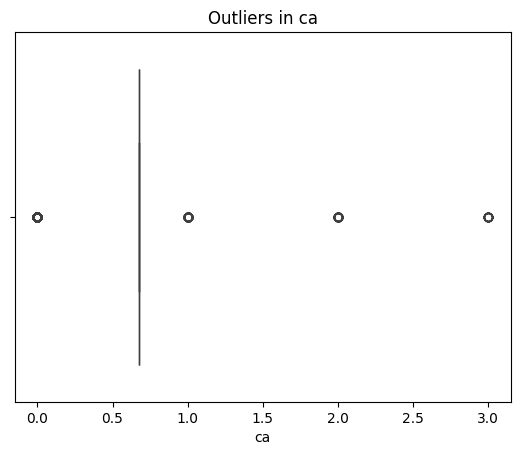

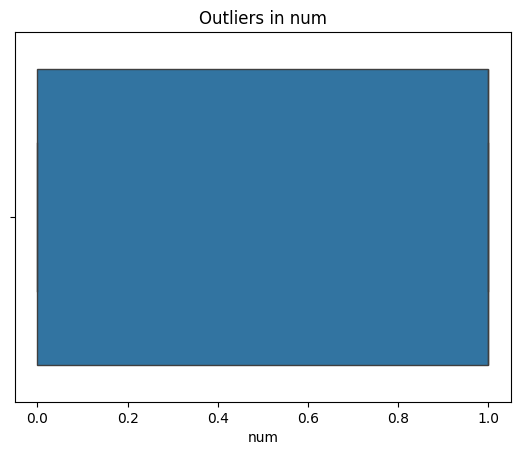


Skewness:
 age                        -0.195994
trestbps                    0.220498
chol                       -0.624062
thalch                     -0.217704
oldpeak                     1.078270
ca                          2.005385
num                        -0.214613
sex_Male                   -1.419879
dataset_Hungary             0.780527
dataset_Switzerland         2.156191
dataset_VA Long Beach       1.372559
cp_atypical angina          1.590234
cp_non-anginal              1.341860
cp_typical angina           4.136230
fbs_True                    1.963595
restecg_normal             -0.404289
restecg_st-t abnormality    1.545645
exang_True                  0.555898
slope_flat                  0.517241
slope_upsloping             1.349474
thal_normal                 1.403930
thal_reversable defect      1.436010
dtype: float64

Decision Tree Results
Accuracy: 0.8152173913043478
[[62 13]
 [21 88]]
              precision    recall  f1-score   support

         0.0       0.75      0.83

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report



df = pd.read_csv('/content/heart_disease_uci.csv')


print("Basic Info:\n")
print(df.info())

print("\nShape:", df.shape)

print("\nNumerical Summary:\n", df.describe())
print("\nCategorical Summary:\n", df.describe(include='object'))


df['num'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

# 4.1 Univariate Analysis

# Numerical
df.hist(figsize=(12,10))
plt.show()

# Categorical
for col in df.select_dtypes(include='object').columns:
    sns.countplot(x=col, data=df)
    plt.title(f"{col} Distribution")
    plt.show()

for col in df.select_dtypes(include=np.number).columns:
    if col != 'num':
        sns.boxplot(x='num', y=col, data=df)
        plt.title(f"{col} vs Target")
        plt.show()

# Categorical vs Target
for col in df.select_dtypes(include='object').columns:
    sns.countplot(x=col, hue='num', data=df)
    plt.title(f"{col} vs Target")
    plt.show()


# =========================================
# Step 5 | Data Preprocessing
# =========================================

# 5.1 Remove Irrelevant Features
df.drop(['id'], axis=1, inplace=True)  # id not useful

# 5.2 Missing Values
imputer = SimpleImputer(strategy='mean')
df[df.select_dtypes(include=np.number).columns] = imputer.fit_transform(
    df.select_dtypes(include=np.number)
)

# 5.3 Outliers
for col in df.select_dtypes(include=np.number).columns:
    sns.boxplot(x=df[col])
    plt.title(f"Outliers in {col}")
    plt.show()

# 5.4 Encoding
df = pd.get_dummies(df, drop_first=True)

# 5.5 Feature Scaling + Split
X = df.drop('num', axis=1)
y = df['num']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 5.6 Skewness
print("\nSkewness:\n", df.skew())


# =========================================
# Step 6 | Decision Tree
# =========================================

dt = DecisionTreeClassifier(random_state=42)

param_dt = {
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5, 10]
}

grid_dt = GridSearchCV(dt, param_dt, cv=5)
grid_dt.fit(X_train, y_train)

best_dt = grid_dt.best_estimator_
y_pred_dt = best_dt.predict(X_test)

print("\nDecision Tree Results")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))


# =========================================
# Step 7 | Random Forest
# =========================================

rf = RandomForestClassifier(random_state=42)

param_rf = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10]
}

grid_rf = GridSearchCV(rf, param_rf, cv=5)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
y_pred_rf = best_rf.predict(X_test)

print("\nRandom Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


# =========================================
# Step 8 | KNN
# =========================================

knn = KNeighborsClassifier()

param_knn = {'n_neighbors': [3,5,7,9]}

grid_knn = GridSearchCV(knn, param_knn, cv=5)
grid_knn.fit(X_train, y_train)

best_knn = grid_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test)

print("\nKNN Results")
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print(confusion_matrix(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))


# =========================================
# Step 9 | SVM
# =========================================

svm = SVC()

param_svm = {'C':[0.1,1,10], 'kernel':['linear','rbf']}

grid_svm = GridSearchCV(svm, param_svm, cv=5)
grid_svm.fit(X_train, y_train)

best_svm = grid_svm.best_estimator_
y_pred_svm = best_svm.predict(X_test)

print("\nSVM Results")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))


# =========================================
# Step 10 | Conclusion
# =========================================

print("\n✅ Model Comparison Completed")
print("Random Forest usually gives best performance.")
print("Proper preprocessing and tuning improved accuracy.")
print("This model can help in early detection of heart disease.")